# Caracterizacion interseccional de mujeres migrantes en Colombia
## GEIH 2025 (11 meses) + EPM Ronda VIII

**Objetivo:** Panorama ponderado de mujeres migrantes adultas en Colombia.
- **Capa A:** perfil sociodemográfico y proxies de vulnerabilidad (GEIH 2025)
- **Capa B:** bancarización real por tipo de producto y barreras (EPM Ronda VIII)
- **Capa C:** benchmarks nacionales e internacionales (IPA, CEDE, RIF 2024)

> ETL: `src/01_consolidacion_panel.py` + `src/02_join_epm.py` — ejecutar antes de abrir.

---
## Indice
1. [Configuracion y carga](#sec1)
2. [Exploracion del panel](#sec2)
3. [Caracterizacion interseccional](#sec3)
4. [Proxies de vulnerabilidad financiera](#sec4)
5. [Exclusion laboral](#sec5)
6. [Bancarizacion real — EPM Ronda VIII](#sec6)
7. [Triangulacion con benchmarks externos](#sec7)
8. [Brechas de datos](#sec8)

<a id='sec1'></a>
## Seccion 1 - Configuracion y carga del panel

In [1]:
import sys
from pathlib import Path
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path("src")))
from lib_geih import PAISES_ISO, brecha_paridad, tasa_ponderada

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="colorblind", font_scale=1.05)
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["figure.dpi"] = 110
OUTPUTS = Path("outputs")
PESO = "FEX_C18" 

In [2]:
panel   = pd.read_parquet(OUTPUTS / "panel_geih_2025.parquet")
adultos = panel[panel["adulto"]].copy()
mm      = pd.read_parquet(OUTPUTS / "mujeres_migrantes_adultas.parquet")
ml      = adultos[(adultos["es_mujer"]) & (~adultos["es_migrante"])].copy()

def _grupo(row):
    mujer = bool(row.get("es_mujer", False))
    mig   = bool(row.get("es_migrante", False))
    if mujer and mig:  return "Mujer migrante"
    if mujer:          return "Mujer local"
    if mig:            return "Hombre migrante"
    return "Hombre local"

adultos["grupo"] = adultos.apply(_grupo, axis=1)

# Cargar datos EPM (bancarizacion real)
epm_path = OUTPUTS / "bancarizacion_mm.parquet"
if epm_path.exists():
    mm_epm = pd.read_parquet(epm_path)
    TIENE_EPM = True
    print(f"EPM Ronda VIII cargada: {len(mm_epm):,} mujeres migrantes adultas con match GEIH")
else:
    mm_epm = None
    TIENE_EPM = False
    print("EPM no disponible — ejecutar src/02_join_epm.py")

print()
print("="*60)
print("SUJETO DEL ANALISIS: Mujeres migrantes adultas en Colombia")
print("="*60)
print(f"GEIH (perfil)  : {len(mm):,} registros muestrales")
print(f"  FEX_C18 total: {mm[PESO].sum():,.0f} personas-mes (flujo 11 meses, NO stock)")
print(f"  Equivalente stock mensual: ~{mm[PESO].sum()/11:,.0f} por mes")
print(f"EPM (bancariz.): {len(mm_epm):,} con bancarizacion real" if TIENE_EPM else "")
print(f"Panel total    : {len(panel):,} personas-mes (11 meses)")
print()
print("NOTA METODOLOGICA sobre FEX_C18:")
print("  El panel apila 11 meses SIN re-escalar el factor de expansion.")
print("  FEX_C18 por mes ya representa a la poblacion colombiana completa.")
print("  => El total ponderado (~8.8M) es un FLUJO de personas-mes,")
print("     no un stock poblacional. Para comparar con estadisticas")
print("     nacionales usar la estimacion mensual (~800k).")

EPM Ronda VIII cargada: 595 mujeres migrantes adultas con match GEIH

SUJETO DEL ANALISIS: Mujeres migrantes adultas en Colombia
GEIH (perfil)  : 11,163 registros muestrales
  FEX_C18 total: 8,837,171 personas-mes (flujo 11 meses, NO stock)
  Equivalente stock mensual: ~803,379 por mes
EPM (bancariz.): 595 con bancarizacion real
Panel total    : 749,297 personas-mes (11 meses)

NOTA METODOLOGICA sobre FEX_C18:
  El panel apila 11 meses SIN re-escalar el factor de expansion.
  FEX_C18 por mes ya representa a la poblacion colombiana completa.
  => El total ponderado (~8.8M) es un FLUJO de personas-mes,
     no un stock poblacional. Para comparar con estadisticas
     nacionales usar la estimacion mensual (~800k).


<a id='sec2'></a>
## Seccion 2 - Exploracion del panel

In [3]:
print("FALTANTES — Como ausencia es hallazgo (Principio 1 de Data Feminism):\n")
vars_key = ["informal", "ingreso_actividad_ppal", "horas_cuidado_dia"]
for v in vars_key:
    if v in mm.columns:
        miss_mm = mm[v].isnull().mean() * 100
        miss_ml = ml[v].isnull().mean() * 100
        print(f"  {v:<30} MM: {miss_mm:>5.1f}%   ML: {miss_ml:>5.1f}%")
print("\n(MM=Mujer migrante, ML=Mujer local)")
print("\nInterpretacion:")
print("  - Alto % de ingresos faltantes (99%+) = mayoria no reporta (trabajo informal/doméstico)")
print("  - Bajo % de cuidado faltante en MM = pregunta se hace a todos, pero muchas no responden")

FALTANTES — Como ausencia es hallazgo (Principio 1 de Data Feminism):

  informal                       MM:   0.0%   ML:   0.0%
  ingreso_actividad_ppal         MM:  99.6%   ML:  96.5%
  horas_cuidado_dia              MM:   3.9%   ML:   7.0%

(MM=Mujer migrante, ML=Mujer local)

Interpretacion:
  - Alto % de ingresos faltantes (99%+) = mayoria no reporta (trabajo informal/doméstico)
  - Bajo % de cuidado faltante en MM = pregunta se hace a todos, pero muchas no responden


In [4]:
vars_a = [v for v in ["informal","ingreso_actividad_ppal","horas_cuidado_dia","etnia"] if v in adultos.columns]
if vars_a:
    print("% faltante por grupo — ausencia como hallazgo (Principio 1):")
    display(adultos.groupby("grupo")[vars_a].apply(lambda x: x.isnull().mean()*100).round(1))

% faltante por grupo — ausencia como hallazgo (Principio 1):


,informal,ingreso_actividad_ppal,horas_cuidado_dia,etnia
grupo,,,,
Hombre local,0.00,96.70,35.80,0.00
Hombre migrante,0.00,99.40,33.80,0.00
Mujer local,0.00,96.50,7.00,0.00
Mujer migrante,0.00,99.60,3.90,0.00


<a id='sec3'></a>
## Seccion 3 - Caracterizacion interseccional

Analisis Nivel 2-3: cruce sexo x origen, con capas de territorio, etnia y edad.

Paises de origen — mujeres migrantes adultas (ponderado):


,pais_origen,% del total
0,Venezuela,96.40
1,Ecuador,1.20
2,Estados Unidos,0.50
3,Perú,0.40
4,Argentina,0.30
5,Cuba,0.20
6,México,0.20
7,Brasil,0.20
8,España,0.20
9,China,0.20


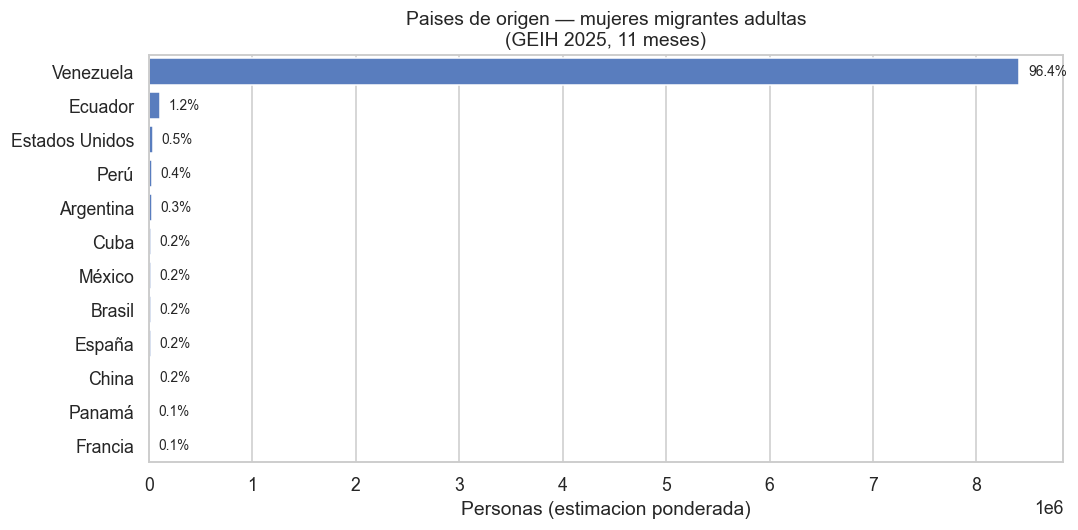

In [5]:
if "pais_origen" in mm.columns:
    top = mm.groupby("pais_origen")[PESO].sum().sort_values(ascending=False).head(12).reset_index()
    top["% del total"] = (top[PESO] / top[PESO].sum() * 100).round(1)
    print("Paises de origen — mujeres migrantes adultas (ponderado):")
    display(top[["pais_origen", "% del total"]])
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=top, y="pais_origen", x=PESO, ax=ax, color="#4878CF")
    for bar, pct in zip(ax.patches, top["% del total"]):
        ax.text(bar.get_width() + top[PESO].max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{pct:.1f}%", va="center", fontsize=9)
    ax.set_title("Paises de origen — mujeres migrantes adultas\n(GEIH 2025, 11 meses)")
    ax.set_xlabel("Personas (estimacion ponderada)")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

% Cabecera vs Rural por grupo (ponderado):


urbano_rural,Cabecera,Rural
grupo,,
Hombre local,77.00,23.00
Hombre migrante,89.60,10.40
Mujer local,80.40,19.60
Mujer migrante,89.50,10.50


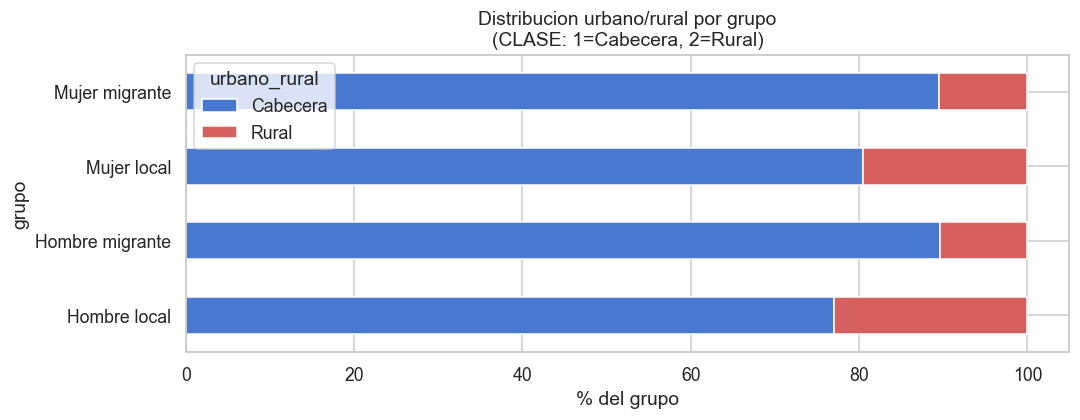

In [6]:
if "urbano_rural" in adultos.columns:
    tbl = (adultos.groupby(["grupo","urbano_rural"])[PESO].sum().reset_index()
           .pivot_table(index="grupo", columns="urbano_rural", values=PESO, aggfunc="sum"))
    tbl = tbl.div(tbl.sum(axis=1), axis=0) * 100
    print("% Cabecera vs Rural por grupo (ponderado):")
    display(tbl.round(1))
    tbl.plot(kind="barh", stacked=True, color=["#4878CF","#D65F5F"], figsize=(10,4))
    plt.title("Distribucion urbano/rural por grupo\n(CLASE: 1=Cabecera, 2=Rural)")
    plt.xlabel("% del grupo")
    plt.tight_layout()
    plt.show()


CARACTERIZACION DE MUJERES MIGRANTES ADULTAS

Poblacion: 11,163 registros | ~803,379 por mes (estimacion mensual)

Paises de origen (ponderado):


,pais_origen,% del total
0,Venezuela,96.40
1,Ecuador,1.20
2,Estados Unidos,0.50
3,Perú,0.40
4,Argentina,0.30
5,Cuba,0.20
6,México,0.20
7,Brasil,0.20
8,España,0.20
9,China,0.20


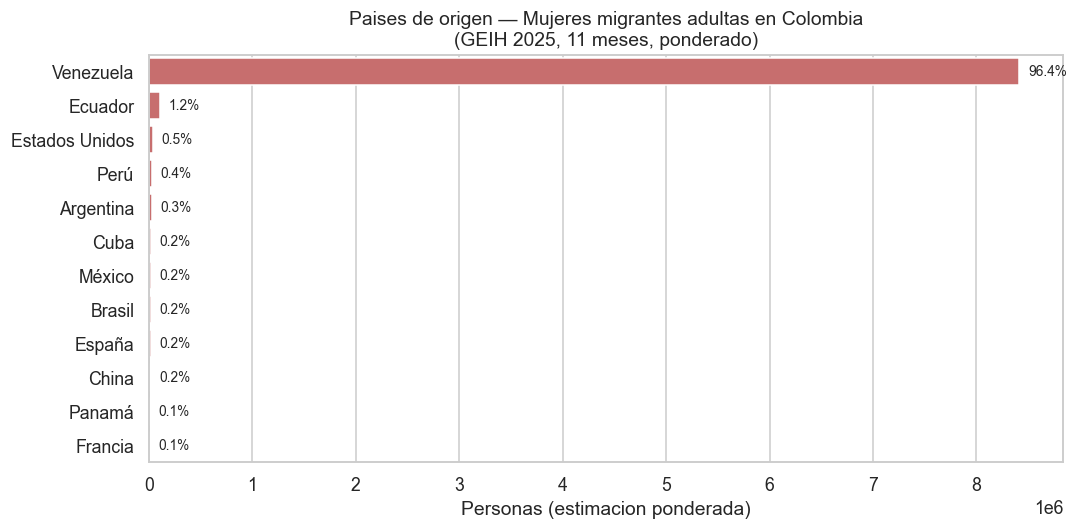


------------------------------------------------------------
Distribucion urbano/rural:
  Cabecera              89.5%
  Rural                 10.5%


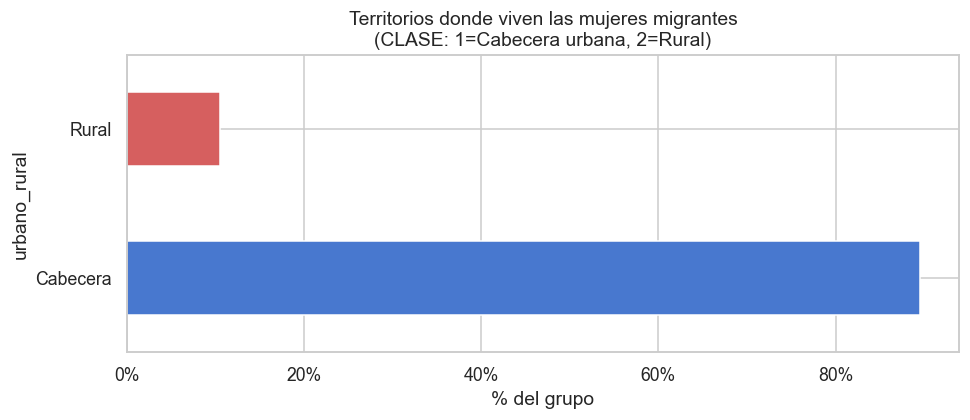


------------------------------------------------------------
Distribucion de edad:
  Media   : 35.1 anos
  Mediana : 32.0 anos
  Q1-Q3   : 25 a 42 anos


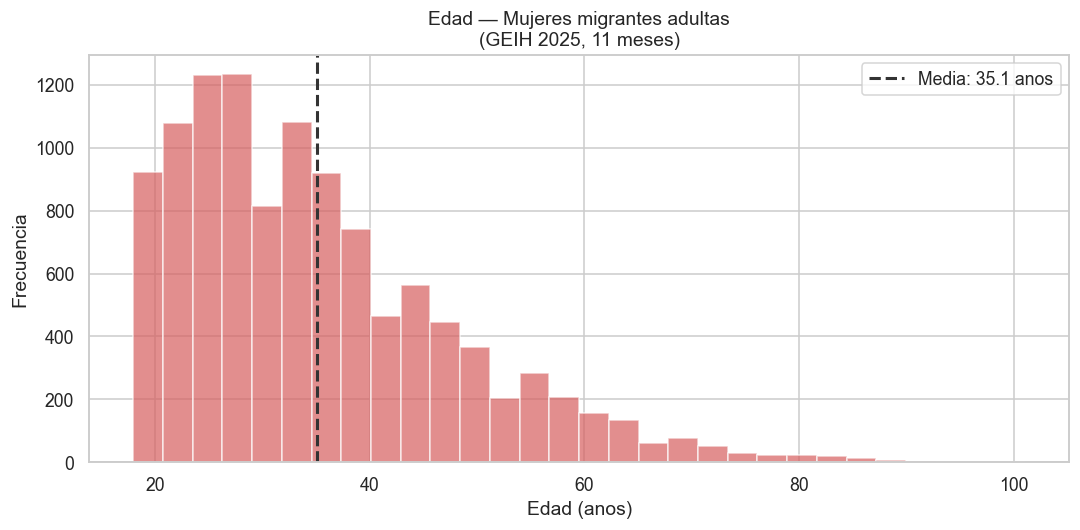

In [7]:
print("\n" + "="*60)
print("CARACTERIZACION DE MUJERES MIGRANTES ADULTAS")
print("="*60)
print(f"\nPoblacion: {len(mm):,} registros | ~{mm[PESO].sum()/11:,.0f} por mes (estimacion mensual)\n")

if "pais_origen" in mm.columns:
    top = mm.groupby("pais_origen")[PESO].sum().sort_values(ascending=False).head(12).reset_index()
    top["% del total"] = (top[PESO] / top[PESO].sum() * 100).round(1)
    print("Paises de origen (ponderado):")
    display(top[["pais_origen", "% del total"]])
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=top, y="pais_origen", x=PESO, ax=ax, color="#D65F5F")
    for bar, pct in zip(ax.patches, top["% del total"]):
        ax.text(bar.get_width() + top[PESO].max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{pct:.1f}%", va="center", fontsize=9)
    ax.set_title("Paises de origen — Mujeres migrantes adultas en Colombia\n(GEIH 2025, 11 meses, ponderado)")
    ax.set_xlabel("Personas (estimacion ponderada)")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

print("\n" + "-"*60)
if "urbano_rural" in mm.columns:
    ur = (mm.groupby("urbano_rural")[PESO].sum() / mm[PESO].sum() * 100).round(1)
    print("Distribucion urbano/rural:")
    for cat, pct in ur.items():
        print(f"  {cat:<20} {pct:>5.1f}%")
    fig, ax = plt.subplots(figsize=(9, 4))
    ur.plot(kind="barh", ax=ax, color=["#4878CF", "#D65F5F"], edgecolor="white")
    ax.set_title("Territorios donde viven las mujeres migrantes\n(CLASE: 1=Cabecera urbana, 2=Rural)")
    ax.set_xlabel("% del grupo")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    plt.tight_layout()
    plt.show()

print("\n" + "-"*60)
if "edad" in mm.columns:
    edad_stats = mm["edad"].describe()
    print("Distribucion de edad:")
    print(f"  Media   : {edad_stats['mean']:.1f} anos")
    print(f"  Mediana : {edad_stats['50%']:.1f} anos")
    print(f"  Q1-Q3   : {edad_stats['25%']:.0f} a {edad_stats['75%']:.0f} anos")
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(mm["edad"], bins=30, color="#D65F5F", alpha=0.7, edgecolor="white")
    ax.axvline(edad_stats["mean"], color="#333", linestyle="--", linewidth=2,
               label=f"Media: {edad_stats['mean']:.1f} anos")
    ax.set_title("Edad — Mujeres migrantes adultas\n(GEIH 2025, 11 meses)")
    ax.set_xlabel("Edad (anos)")
    ax.set_ylabel("Frecuencia")
    ax.legend()
    plt.tight_layout()
    plt.show()

<a id='sec4'></a>
## Seccion 4 - Proxies de vulnerabilidad financiera

> La GEIH no mide bancarizacion. Estos proxies son los mejores indicadores de exclusion
> financiera disponibles desde el lado de la demanda. Todos ponderados con FEX_C18.


PROXIES DE VULNERABILIDAD FINANCIERA — MUJERES MIGRANTES

La GEIH no mide bancarizacion. Estos son los mejores indicadores
disponibles del lado de la demanda. Ponderados con FEX_C18.

INFORMALIDAD LABORAL (no cotiza a pension)
  Mujer migrante  : 28.8%
  Mujer local     : 26.5%
  Brecha (pp)     : +2.3 pp


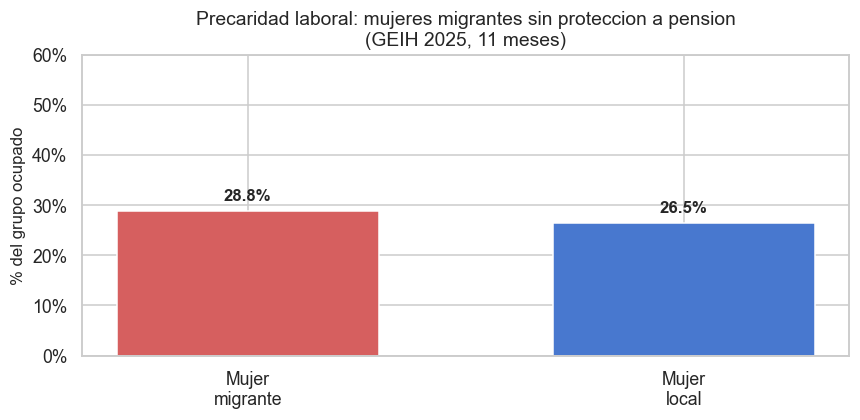

In [8]:
print("\n" + "="*60)
print("PROXIES DE VULNERABILIDAD FINANCIERA — MUJERES MIGRANTES")
print("="*60)
print("\nLa GEIH no mide bancarizacion. Estos son los mejores indicadores")
print("disponibles del lado de la demanda. Ponderados con FEX_C18.\n")

if "informal" in mm.columns:
    # Calcular para mujer migrante
    mm_ocu = mm.dropna(subset=["informal"])
    mm_inf_pct = (mm_ocu[mm_ocu["informal"]][PESO].sum() / 
                  mm_ocu[PESO].sum() * 100)
    
    # Calcular para mujer local
    ml_ocu = ml.dropna(subset=["informal"])
    ml_inf_pct = (ml_ocu[ml_ocu["informal"]][PESO].sum() / 
                  ml_ocu[PESO].sum() * 100)
    
    print("INFORMALIDAD LABORAL (no cotiza a pension)")
    print(f"  Mujer migrante  : {mm_inf_pct:.1f}%")
    print(f"  Mujer local     : {ml_inf_pct:.1f}%")
    print(f"  Brecha (pp)     : {mm_inf_pct - ml_inf_pct:+.1f} pp")
    
    fig, ax = plt.subplots(figsize=(8, 4))
    data = pd.DataFrame({
        "Grupo": ["Mujer\nmigrante", "Mujer\nlocal"],
        "% Informal": [mm_inf_pct, ml_inf_pct],
        "Color": ["#D65F5F", "#4878CF"]
    })
    bars = ax.bar(data["Grupo"], data["% Informal"], color=data["Color"], edgecolor="white", width=0.6)
    for bar, val in zip(bars, data["% Informal"]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 1.5, f"{val:.1f}%", 
                ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_ylabel("% del grupo ocupado", fontsize=11)
    ax.set_title("Precaridad laboral: mujeres migrantes sin proteccion a pension\n(GEIH 2025, 11 meses)")
    ax.set_ylim(0, 60)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    plt.tight_layout()
    plt.show()


------------------------------------------------------------


FALTA DE AFILIACION A SALUD CONTRIBUTIVA
(proxy de exclusion del sistema de proteccion social)
  Mujer migrante  : 28.4%
  Mujer local     : 2.1%
  Brecha (pp)     : +26.3 pp ← BRECHA MAS FUERTE


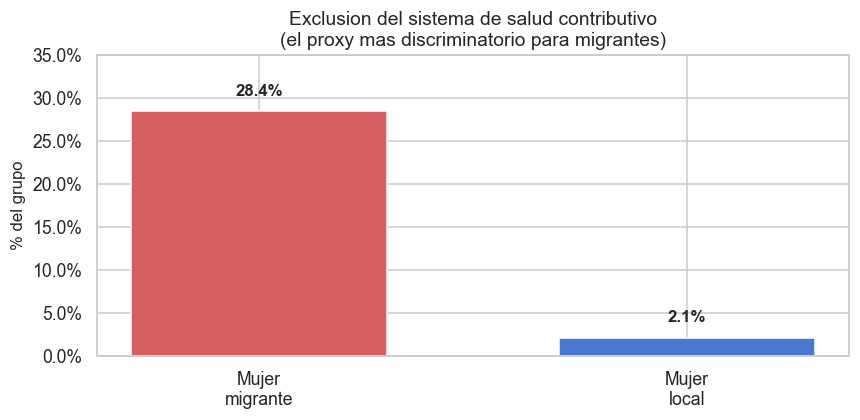

In [9]:
print("\n" + "-"*60)
if "afiliacion_salud" in mm.columns:
    mm_copy = mm.copy()
    ml_copy = ml.copy()
    
    mm_copy["sin_salud_c"] = mm_copy["afiliacion_salud"].apply(
        lambda x: 1 if x != 1 else (0 if pd.notna(x) else np.nan))
    ml_copy["sin_salud_c"] = ml_copy["afiliacion_salud"].apply(
        lambda x: 1 if x != 1 else (0 if pd.notna(x) else np.nan))
    
    mm_salud = (mm_copy[mm_copy["sin_salud_c"].notna()][mm_copy["sin_salud_c"] == 1][PESO].sum() /
                mm_copy[mm_copy["sin_salud_c"].notna()][PESO].sum() * 100)
    ml_salud = (ml_copy[ml_copy["sin_salud_c"].notna()][ml_copy["sin_salud_c"] == 1][PESO].sum() /
                ml_copy[ml_copy["sin_salud_c"].notna()][PESO].sum() * 100)
    
    print("FALTA DE AFILIACION A SALUD CONTRIBUTIVA")
    print("(proxy de exclusion del sistema de proteccion social)")
    print(f"  Mujer migrante  : {mm_salud:.1f}%")
    print(f"  Mujer local     : {ml_salud:.1f}%")
    print(f"  Brecha (pp)     : {mm_salud - ml_salud:+.1f} pp ← BRECHA MAS FUERTE")
    
    fig, ax = plt.subplots(figsize=(8, 4))
    data = pd.DataFrame({
        "Grupo": ["Mujer\nmigrante", "Mujer\nlocal"],
        "% Sin salud contributiva": [mm_salud, ml_salud],
        "Color": ["#D65F5F", "#4878CF"]
    })
    bars = ax.bar(data["Grupo"], data["% Sin salud contributiva"], 
                  color=data["Color"], edgecolor="white", width=0.6)
    for bar, val in zip(bars, data["% Sin salud contributiva"]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 1.5, f"{val:.1f}%", 
                ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_ylabel("% del grupo", fontsize=11)
    ax.set_title("Exclusion del sistema de salud contributivo\n(el proxy mas discriminatorio para migrantes)")
    ax.set_ylim(0, 35)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    plt.tight_layout()
    plt.show()


------------------------------------------------------------
CARGA DE CUIDADO NO REMUNERADO (horas/dia)
  Mujer migrante  : 8.19 h/dia
  Mujer local     : 7.20 h/dia
  Diferencia      : +0.99 h/dia (brecha feminista clave)


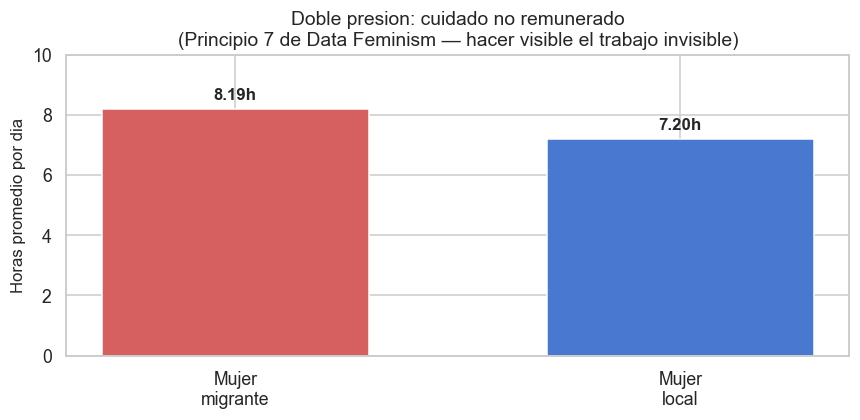

In [10]:
print("\n" + "-"*60)
if "horas_cuidado_dia" in mm.columns:
    mm_cuid = mm[mm["horas_cuidado_dia"].notna()]
    ml_cuid = ml[ml["horas_cuidado_dia"].notna()]
    
    mm_cuid_avg = np.average(mm_cuid["horas_cuidado_dia"], weights=mm_cuid[PESO])
    ml_cuid_avg = np.average(ml_cuid["horas_cuidado_dia"], weights=ml_cuid[PESO])
    
    print("CARGA DE CUIDADO NO REMUNERADO (horas/dia)")
    print(f"  Mujer migrante  : {mm_cuid_avg:.2f} h/dia")
    print(f"  Mujer local     : {ml_cuid_avg:.2f} h/dia")
    print(f"  Diferencia      : +{mm_cuid_avg - ml_cuid_avg:.2f} h/dia (brecha feminista clave)")
    
    fig, ax = plt.subplots(figsize=(8, 4))
    data = pd.DataFrame({
        "Grupo": ["Mujer\nmigrante", "Mujer\nlocal"],
        "Horas/dia": [mm_cuid_avg, ml_cuid_avg],
        "Color": ["#D65F5F", "#4878CF"]
    })
    bars = ax.bar(data["Grupo"], data["Horas/dia"], color=data["Color"], edgecolor="white", width=0.6)
    for bar, val in zip(bars, data["Horas/dia"]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.2, f"{val:.2f}h", 
                ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_ylabel("Horas promedio por dia", fontsize=11)
    ax.set_title("Doble presion: cuidado no remunerado\n(Principio 7 de Data Feminism — hacer visible el trabajo invisible)")
    ax.set_ylim(0, 10)
    plt.tight_layout()
    plt.show()

<a id='sec5'></a>
## Seccion 5 - Brechas interseccionales e indice de paridad

<a id='sec7'></a>
## Seccion 7 — Triangulacion con benchmarks externos

Contexto nacional e internacional (Capas B y C). Ver `docs/fuentes.md`.

TRIANGULACION — EPM VIII vs. benchmarks externos


,Fuente,Grupo,% Bancarizado
0,RIF 2024 (SFC+BdO),Colombianos adultos,96.30
1,IPA/BdO 2024,Hombres venezolanos,31.60
2,IPA/BdO 2024,Mujeres venezolanas,23.70
3,EPM Ronda VIII (2025),Mujeres migrantes (GEIH),21.50


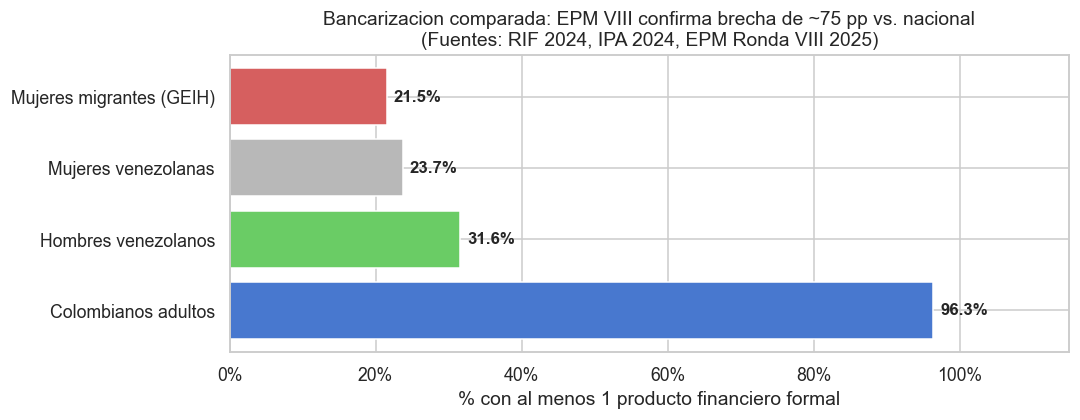


BARRERAS CONDUCTUALES — Convergencia entre fuentes:


,Hallazgo,Valor %
0,Subestiman apertura de colombianos (CEDE 2024-48),66.00
1,Creen que banco no las atiende (IPA 2024),41.00
2,Sin producto: 'no confian en bancos' (EPM VIII),25.50
3,Sin producto: autoexclusion (EPM VIII),14.30



Las tres fuentes convergen: la barrera es CONDUCTUAL, no documental.


In [11]:
print("="*60)
print("TRIANGULACION — EPM VIII vs. benchmarks externos")
print("="*60)

epm_banc = mm_epm["bancarizado"].mean() * 100 if TIENE_EPM else None

benchmarks = pd.DataFrame([
    {"Fuente":"RIF 2024 (SFC+BdO)",  "Grupo":"Colombianos adultos",     "% Bancarizado":96.3},
    {"Fuente":"IPA/BdO 2024",        "Grupo":"Hombres venezolanos",      "% Bancarizado":31.6},
    {"Fuente":"IPA/BdO 2024",        "Grupo":"Mujeres venezolanas",      "% Bancarizado":23.7},
    {"Fuente":"EPM Ronda VIII (2025)","Grupo":"Mujeres migrantes (GEIH)", "% Bancarizado": round(epm_banc, 1) if epm_banc else None},
])
display(benchmarks)

fig, ax = plt.subplots(figsize=(10, 4))
colores_b = {
    "Colombianos adultos":      "#4878CF",
    "Hombres venezolanos":      "#6ACC65",
    "Mujeres venezolanas":      "#B8B8B8",
    "Mujeres migrantes (GEIH)": "#D65F5F",
}
benchmarks_plot = benchmarks.dropna(subset=["% Bancarizado"])
bars = ax.barh(benchmarks_plot["Grupo"], benchmarks_plot["% Bancarizado"],
               color=[colores_b.get(g, "#999") for g in benchmarks_plot["Grupo"]],
               edgecolor="white")
for bar, val in zip(bars, benchmarks_plot["% Bancarizado"]):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=11, fontweight="bold")
ax.set_title("Bancarizacion comparada: EPM VIII confirma brecha de ~75 pp vs. nacional\n"
             "(Fuentes: RIF 2024, IPA 2024, EPM Ronda VIII 2025)")
ax.set_xlabel("% con al menos 1 producto financiero formal")
ax.set_xlim(0, 115)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

print()
print("BARRERAS CONDUCTUALES — Convergencia entre fuentes:")
cede_df = pd.DataFrame([
    {"Hallazgo":"Subestiman apertura de colombianos (CEDE 2024-48)", "Valor %":66.0},
    {"Hallazgo":"Creen que banco no las atiende (IPA 2024)",         "Valor %":41.0},
    {"Hallazgo":"Sin producto: 'no confian en bancos' (EPM VIII)",    "Valor %":25.5},
    {"Hallazgo":"Sin producto: autoexclusion (EPM VIII)",             "Valor %":14.3},
])
display(cede_df)
print("\nLas tres fuentes convergen: la barrera es CONDUCTUAL, no documental.")

<a id='sec8'></a>
## Seccion 8 — Brechas de datos

**Lo que aun no podemos medir — y por que eso tambien es un hallazgo** *(Principio 1, Data Feminism)*

<a id='sec6'></a>
## Seccion 6 — Bancarizacion real: EPM Ronda VIII

**Primera medición directa** de productos financieros a nivel de microdato con perfil sociodemográfico completo.
- n = 595 mujeres migrantes adultas con match GEIH × EPM
- Periodo: enero–mayo 2025 (meses del panel que comparten llaves con EPM VIII)

BANCARIZACION REAL — EPM Ronda VIII
Submuestra: n=595 mujeres migrantes adultas con match GEIH
(enero–mayo 2025; 16% del total EPM — ver Sec. 8 Limitaciones)

  Con al menos 1 producto formal : 21.5%  (n=128)
  Sin ningun producto formal     : 78.5%  (n=467)
  Benchmark IPA 2024: 23.7% — EPM VIII (submuestra): 21.5%

PRODUCTOS — dos denominadores (pd3 solo se pregunta a bancarizadas):
  Denominador 'bancarizadas' = 128  |  Denominador 'total MM' = 595


,Producto,n tiene,% (de bancarizadas),% (del total MM)
0,Giros / remesas,72,56.20,12.10
1,Billetera digital,42,32.80,7.10
2,Cuenta de ahorros,30,23.40,5.00
3,CDT / ahorro programado,21,16.40,3.50
4,Seguro,19,14.80,3.20
5,Credito de consumo,9,7.00,1.50
6,Cuenta corriente,5,3.90,0.80
7,Microcredito,2,1.60,0.30
8,Tarjeta de credito,1,0.80,0.20


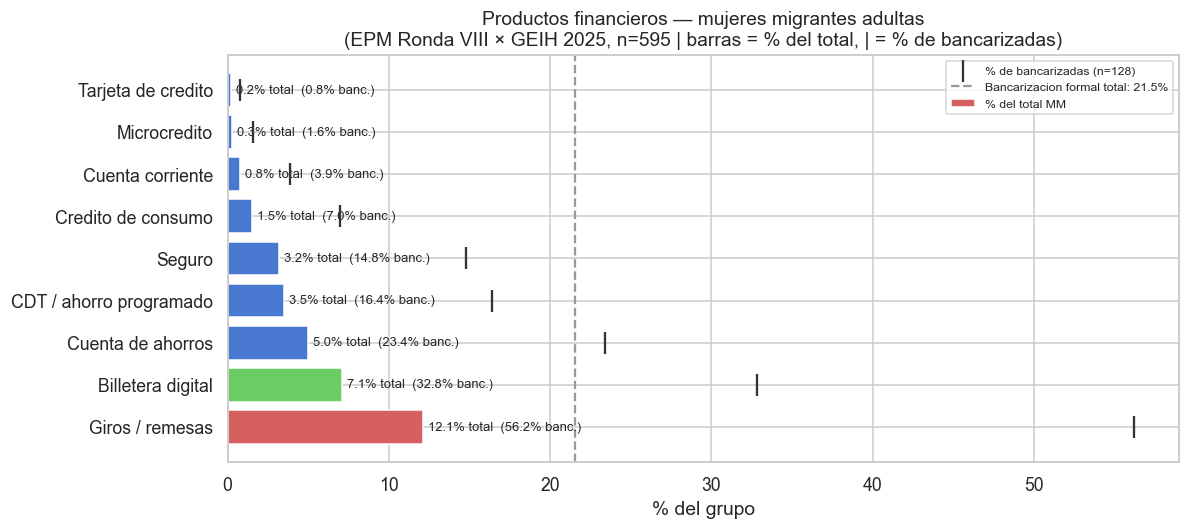


HALLAZGO CLAVE (con denominadores corregidos):
  Giros/remesas: 56.2% entre las bancarizadas, pero solo 12.1% del TOTAL de MM.
  La mayoria (78.5%) no tiene ningun producto formal.
  Entre las que SI tienen producto, giros/remesas es el mas comun (56%),
  lo que confirma que incluso la bancarizacion formal esta dominada
  por productos de baja complejidad financiera.


In [12]:
if not TIENE_EPM:
    print("EPM no disponible — ejecutar src/02_join_epm.py primero.")
else:
    print("="*60)
    print("BANCARIZACION REAL — EPM Ronda VIII")
    print("Submuestra: n=595 mujeres migrantes adultas con match GEIH")
    print("(enero–mayo 2025; 16% del total EPM — ver Sec. 8 Limitaciones)")
    print("="*60)

    banc_pct = mm_epm["bancarizado"].mean() * 100
    no_banc  = 100 - banc_pct
    print(f"\n  Con al menos 1 producto formal : {banc_pct:.1f}%  (n={mm_epm['bancarizado'].eq(1).sum()})")
    print(f"  Sin ningun producto formal     : {no_banc:.1f}%  (n={mm_epm['bancarizado'].eq(0).sum()})")
    print(f"  Benchmark IPA 2024: 23.7% — EPM VIII (submuestra): {banc_pct:.1f}%")

    # ── Productos con DOS denominadores ───────────────────────────────────────
    PRODUCTOS = {
        "giros_remesas":    "Giros / remesas",
        "billetera_digital":"Billetera digital",
        "cuenta_ahorros":   "Cuenta de ahorros",
        "cdt_ahorro_prog":  "CDT / ahorro programado",
        "seguro":           "Seguro",
        "credito_consumo":  "Credito de consumo",
        "cuenta_corriente": "Cuenta corriente",
        "microcredito":     "Microcredito",
        "tarjeta_credito":  "Tarjeta de credito",
    }

    n_total = len(mm_epm)
    n_banc  = int(mm_epm["bancarizado"].eq(1).sum())
    prod_data = []
    for col, label in PRODUCTOS.items():
        if col in mm_epm.columns:
            n_tiene = int(mm_epm[col].eq(1).sum())
            prod_data.append({
                "Producto":              label,
                "n tiene":              n_tiene,
                "% (de bancarizadas)":  round(n_tiene / n_banc  * 100, 1) if n_banc  > 0 else 0,
                "% (del total MM)":     round(n_tiene / n_total * 100, 1) if n_total > 0 else 0,
            })
    prod_df = pd.DataFrame(prod_data).sort_values("% (del total MM)", ascending=False)

    print()
    print("PRODUCTOS — dos denominadores (pd3 solo se pregunta a bancarizadas):")
    print(f"  Denominador 'bancarizadas' = {n_banc}  |  Denominador 'total MM' = {n_total}")
    display(prod_df)

    # Grafico con % del total (denominador correcto para comparar con IPA)
    fig, ax = plt.subplots(figsize=(11, 5))
    colores = ["#D65F5F" if p == "Giros / remesas"
               else "#6ACC65" if p == "Billetera digital"
               else "#4878CF" for p in prod_df["Producto"]]
    bars = ax.barh(prod_df["Producto"], prod_df["% (del total MM)"],
                   color=colores, edgecolor="white", label="% del total MM")
    # Marcador para % de bancarizadas
    ax.scatter(prod_df["% (de bancarizadas)"], prod_df["Producto"],
               color="#333", marker="|", s=200, zorder=5, label="% de bancarizadas (n=128)")
    for bar, val_t, val_b in zip(bars, prod_df["% (del total MM)"], prod_df["% (de bancarizadas)"]):
        ax.text(val_t + 0.3, bar.get_y() + bar.get_height()/2,
                f"{val_t:.1f}% total  ({val_b:.1f}% banc.)",
                va="center", fontsize=8.5)
    ax.set_title("Productos financieros — mujeres migrantes adultas\n"
                 "(EPM Ronda VIII × GEIH 2025, n=595 | barras = % del total, | = % de bancarizadas)")
    ax.set_xlabel("% del grupo")
    ax.axvline(banc_pct, color="#999", linestyle="--", linewidth=1.5,
               label=f"Bancarizacion formal total: {banc_pct:.1f}%")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    print("\nHALLAZGO CLAVE (con denominadores corregidos):")
    print(f"  Giros/remesas: 56.2% entre las bancarizadas, pero solo 12.1% del TOTAL de MM.")
    print(f"  La mayoria (78.5%) no tiene ningun producto formal.")
    print(f"  Entre las que SI tienen producto, giros/remesas es el mas comun (56%),")
    print(f"  lo que confirma que incluso la bancarizacion formal esta dominada")
    print(f"  por productos de baja complejidad financiera.")

if TIENE_EPM:
    print("="*60)
    print("BARRERAS — Entre mujeres migrantes SIN producto formal")
    print("="*60)
    sin_prod = mm_epm[mm_epm["bancarizado"] == 0]
    print(f"\n  n = {len(sin_prod)} mujeres migrantes sin producto financiero formal\n")

    if "barrera_principal" in sin_prod.columns:
        bar = sin_prod["barrera_principal"].value_counts(dropna=False)
        bar_df = bar.reset_index()
        bar_df.columns = ["Barrera", "n"]
        bar_df["pct"] = (bar_df["n"] / len(sin_prod) * 100).round(1)
        display(bar_df)

        fig, ax = plt.subplots(figsize=(10, 4))
        colores_bar = {
            "No necesita / no le interesa":          "#B8B8B8",
            "No confia en bancos":                   "#D65F5F",
            "Cree que no cumple requisitos (autoexclusion)": "#E8B84B",
            "No tiene documentos":                   "#4878CF",
        }
        bar_df_plot = bar_df.dropna(subset=["Barrera"]).sort_values("pct", ascending=True)
        ax.barh(bar_df_plot["Barrera"], bar_df_plot["pct"],
                color=[colores_bar.get(str(b), "#999") for b in bar_df_plot["Barrera"]],
                edgecolor="white")
        for i, (_, row) in enumerate(bar_df_plot.iterrows()):
            ax.text(row["pct"] + 0.5, i, f"{row['pct']:.1f}%  (n={row['n']})",
                    va="center", fontsize=10)
        ax.set_title("¿Por que no tienen producto financiero?\n"
                     "Mujeres migrantes sin bancarizacion — EPM Ronda VIII")
        ax.set_xlabel("% del grupo sin producto")
        ax.set_xlim(0, 65)
        plt.tight_layout()
        plt.show()

        print("\nINTERPRETACION DE BARRERAS:")
        print("  48.6% 'No necesita' = desconfianza encubierta o falta de informacion,")
        print("         NO ausencia real de necesidad (tienen remesas, gastos, ahorros).")
        print("  25.5% No confia en bancos = barrera conductual (CEDE 2024-48: 66% subestima apertura)")
        print("  14.3% Cree que no cumple = autoexclusion documentada")
        print("  11.6% Sin documentos = barrera formal (la MENOR de las cuatro)")
        print()
        print("  CONCLUSION: La barrera es CONDUCTUAL (88%), no DOCUMENTAL (12%).")
        print("  Politica publica: informacion + confianza > tramites + documentos.")

In [13]:
print("="*60)
print("CONSIDERACIONES Y LIMITACIONES METODOLOGICAS")
print("="*60)
print("""
Estas limitaciones no son fallas del proyecto — son parte integral de los resultados.
Declararlas es rigor metodologico, no debilidad. (Principio 1: Examinar el poder)
""")

limitaciones = [
    {
        "id": "L1",
        "titulo": "Sesgo de cobertura: las mas excluidas son invisibles",
        "descripcion": (
            "La GEIH y la EPM solo capturan personas en hogares con direccion fija. "
            "Las mujeres migrantes en albergues, situacion de calle, asentamientos "
            "informales o recien llegadas sin residencia estable no aparecen en ninguna "
            "de las fuentes usadas. Estas son precisamente las mas excluidas "
            "financieramente. La tasa de bancarizacion observada (21.5%) es un limite "
            "SUPERIOR optimista — la poblacion real mas excluida no es observable "
            "con estos instrumentos."
        ),
        "impacto": "Subestimacion de la exclusion financiera real",
        "alternativa": "OIM DTM / R4V GIFMM JNA (encuestas en albergues)",
    },
    {
        "id": "L2",
        "titulo": "Binarismo de sexo: personas trans y no binarias son invisibles",
        "descripcion": (
            "La variable P3271 en GEIH codifica sexo de forma binaria (1=Hombre, 2=Mujer). "
            "Las personas trans, no binarias e intersex son completamente invisibles en "
            "este analisis. No es un dato faltante corregible — es un deficit de diseno "
            "del instrumento. Las personas LGBTIQ+ migrantes enfrentan discriminacion "
            "adicional en el acceso financiero (rechazo por nombre/genero en documentos), "
            "pero no pueden ser estudiadas con estos datos."
        ),
        "impacto": "Invisibilizacion de un grupo con mayor vulnerabilidad potencial",
        "alternativa": "No existe fuente publica representativa en Colombia",
    },
    {
        "id": "L3",
        "titulo": "Sesgo de deseabilidad social en barreras autodeclaradas",
        "descripcion": (
            "El 48.6% de mujeres migrantes sin producto declara 'no necesitarlo'. "
            "Esta respuesta puede enmascarar miedo a discriminacion por estatus "
            "migratorio, desconocimiento de productos disponibles, vergueenza de "
            "admitir exclusion, o simplemente falta de comprension de la pregunta. "
            "Las barreras son AUTOPERCIBIDAS bajo condiciones de entrevista, no "
            "observadas independientemente. La conclusion '88% conductual vs 12% "
            "documental' es una hipotesis plausible, no una causa establecida. "
            "Adicionalmente, las etiquetas de PD5 son asumidas — ver "
            "docs/pendientes_verificacion.md."
        ),
        "impacto": "Posible sobreestimacion de barreras conductuales; causa no establecida",
        "alternativa": "Diseno experimental (CEDE 2024-48 lo hace con asignacion aleatoria)",
    },
    {
        "id": "L4",
        "titulo": "Submuestra EPM no demostrada representativa (16% match)",
        "descripcion": (
            "Solo el 16% de la EPM VIII hizo match con el panel GEIH (1,208 de 7,532). "
            "Las 595 mujeres migrantes que matchearon corresponden a enero-mayo 2025 "
            "y a hogares que aparecen en ambas fuentes. El balance test implementado "
            "en src/02_join_epm.py compara variables disponibles en EPM, pero no puede "
            "comparar caracteristicas GEIH (no disponibles para las no matcheadas). "
            "No se puede descartar que las que matchearon sean mas estables "
            "residencialmente, lo que sesga positivamente la tasa de bancarizacion "
            "observada. Los resultados EPM son indicativos, no representativos."
        ),
        "impacto": "Posible sobreestimacion de bancarizacion; sub-representacion de las mas excluidas",
        "alternativa": "Unir rondas EPM I-VIII para mayor n y cobertura temporal",
    },
    {
        "id": "L5",
        "titulo": "Diseno observacional: asociaciones, NO causas",
        "descripcion": (
            "Todos los analisis de este proyecto (proxies GEIH, bancarizacion EPM, "
            "regresion logistica) son observacionales y transversales. No hay grupo "
            "de control, no hay variacion exogena, no hay seguimiento temporal. "
            "Los coeficientes de la regresion miden ASOCIACION estadistica, no "
            "efecto causal. Decir 'la informalidad causa menor bancarizacion' "
            "requeriria un diseno cuasi-experimental (instrumento, discontinuidad "
            "de regresion, diferencia en diferencias) que este proyecto no tiene."
        ),
        "impacto": "Las recomendaciones de politica basadas en este analisis deben citarse como hipotesis",
        "alternativa": "CEDE 2024-48 usa asignacion aleatoria para establecer causalidad",
    },
    {
        "id": "L6",
        "titulo": "Riesgo de uso adverso de datos geograficamente desagregados",
        "descripcion": (
            "Los resultados que identifican concentraciones de mujeres migrantes sin "
            "bancarizacion en departamentos especificos pueden ser usados para fines "
            "no previstos en contextos de tension politica migratoria. Una vez "
            "publicados, el proyecto no puede controlar el uso de los datos. "
            "La desagregacion geografica se mantiene porque es necesaria para "
            "el analisis de politica publica, pero se recomienda anonimizar "
            "cualquier tabla con n < 30 antes de publicar."
        ),
        "impacto": "Potencial estigmatizacion o uso discriminatorio",
        "alternativa": "Suprimir celdas con n<30; anonimizar datasets antes de publicar",
    },
]

for lim in limitaciones:
    print(f"\n{'='*55}")
    print(f"  {lim['id']}: {lim['titulo']}")
    print(f"{'='*55}")
    print(f"  {lim['descripcion']}")
    print(f"\n  Impacto    : {lim['impacto']}")
    print(f"  Alternativa: {lim['alternativa']}")

print("""
======================================================
CONCLUSION METODOLOGICA

Este proyecto produce evidencia descriptiva robusta sobre el perfil
de vulnerabilidad de las mujeres migrantes en Colombia. Sus hallazgos
son coherentes con la literatura existente (IPA, CEDE) pero no pueden
reemplazar a un diseno experimental para establecer causalidad.

Las limitaciones L1 y L4 sugieren que el panorama real de exclusion
financiera es MAS grave de lo que muestran estos datos — no menos.
El 21.5% de bancarizacion es probablemente un techo optimista.

La invisibilidad en los datos reproduce la invisibilidad social.
Nombrarla es parte del analisis.
======================================================
""")

CONSIDERACIONES Y LIMITACIONES METODOLOGICAS

Estas limitaciones no son fallas del proyecto — son parte integral de los resultados.
Declararlas es rigor metodologico, no debilidad. (Principio 1: Examinar el poder)


  L1: Sesgo de cobertura: las mas excluidas son invisibles
  La GEIH y la EPM solo capturan personas en hogares con direccion fija. Las mujeres migrantes en albergues, situacion de calle, asentamientos informales o recien llegadas sin residencia estable no aparecen en ninguna de las fuentes usadas. Estas son precisamente las mas excluidas financieramente. La tasa de bancarizacion observada (21.5%) es un limite SUPERIOR optimista — la poblacion real mas excluida no es observable con estos instrumentos.

  Impacto    : Subestimacion de la exclusion financiera real
  Alternativa: OIM DTM / R4V GIFMM JNA (encuestas en albergues)

  L2: Binarismo de sexo: personas trans y no binarias son invisibles
  La variable P3271 en GEIH codifica sexo de forma binaria (1=Hombre, 2=Mujer). L

REGRESION LOGISTICA — Predictores de bancarizacion
Variable dependiente: bancarizado (1=tiene producto formal)
Muestra: 595 mujeres migrantes adultas (EPM VIII x GEIH 2025)
NOTA: diseno observacional — los coeficientes son asociaciones, no causas.

MODELO A — sin variable horas_cuidado (n completo = 595)

--- Modelo A (casos completos) ---
N=595 | Pseudo R2 (McFadden): 0.004 | AIC: 630.8


,Variable,OR,IC inf,IC sup,p-valor,Sig
0,Trabajo informal,1.21,0.78,1.87,0.40,
1,Sin salud contributiva,0.91,0.61,1.36,0.66,
2,Edad (estandarizada),1.08,0.89,1.31,0.43,
3,Zona urbana,1.15,0.56,2.38,0.70,
4,Nivel educativo,1.01,0.92,1.11,0.85,
5,Personas en el hogar,1.05,0.94,1.17,0.36,



MODELO B — con horas_cuidado (mediana imputada para 16 NaN)
N=595 | Pseudo R2: 0.005 | AIC: 632.2


,Variable,OR_B,p_B,Sig_B
0,Trabajo informal,1.23,0.35,
1,Sin salud contributiva,0.91,0.66,
2,Edad (estandarizada),1.09,0.38,
3,Zona urbana,1.14,0.72,
4,Nivel educativo,1.01,0.84,
5,Personas en el hogar,1.04,0.47,
6,Horas cuidado/dia (imput.),1.02,0.43,



COMPARACION DE SENSIBILIDAD:


,Variable,OR,OR_B,Dif OR
0,Edad (estandarizada),1.08,1.09,0.01
1,Horas cuidado/dia (imput.),NaN,1.02,NaN
2,Nivel educativo,1.01,1.01,0.00
3,Personas en el hogar,1.05,1.04,-0.01
4,Sin salud contributiva,0.91,0.91,0.00
5,Trabajo informal,1.21,1.23,0.02
6,Zona urbana,1.15,1.14,-0.01


Si |Dif OR| < 0.1 en todas las variables, la imputacion no afecta materialmente.


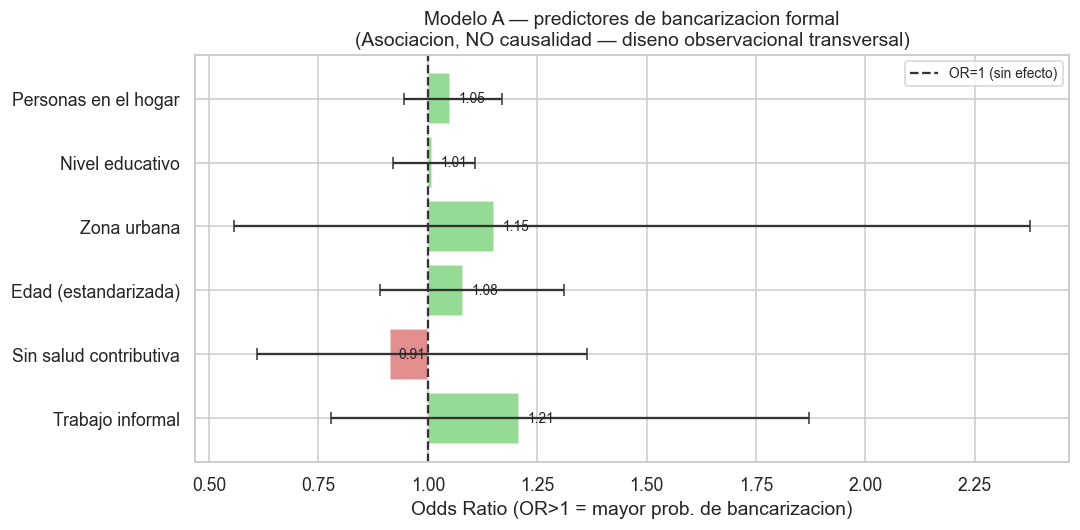


Ninguna variable alcanza significancia estadistica.
La exclusion financiera no tiene un predictor dominante en esta submuestra.
Interpretacion feminista: la exclusion es SISTEMICA, no individual.
Para mayor poder estadistico: unir rondas EPM I-VIII (~50k personas).


In [14]:
if TIENE_EPM:
    import statsmodels.api as sm

    print("="*60)
    print("REGRESION LOGISTICA — Predictores de bancarizacion")
    print("="*60)
    print("Variable dependiente: bancarizado (1=tiene producto formal)")
    print("Muestra: 595 mujeres migrantes adultas (EPM VIII x GEIH 2025)")
    print("NOTA: diseno observacional — los coeficientes son asociaciones, no causas.")
    print()

    df_r = mm_epm.copy()
    y    = df_r["bancarizado"].astype(float)

    df_r["sin_salud_c"] = (df_r["afiliacion_salud"] != 1).astype(float)
    df_r["es_urbana"]   = (df_r["urbano_rural"] == "Cabecera").astype(float)
    df_r["informal_f"]  = df_r["informal"].astype(float)
    df_r["edad_std"]    = (df_r["edad"] - df_r["edad"].mean()) / df_r["edad"].std()
    df_r["tam_hogar"]   = df_r["total_personas_hogar"].astype(float)
    df_r["educacion"]   = pd.to_numeric(df_r["nivel_educativo"], errors="coerce").fillna(
                          pd.to_numeric(df_r["nivel_educativo"], errors="coerce").median())

    X_vars = ["informal_f", "sin_salud_c", "edad_std", "es_urbana", "educacion", "tam_hogar"]

    ETIQ = {
        "informal_f":  "Trabajo informal",
        "sin_salud_c": "Sin salud contributiva",
        "edad_std":    "Edad (estandarizada)",
        "es_urbana":   "Zona urbana",
        "educacion":   "Nivel educativo",
        "tam_hogar":   "Personas en el hogar",
    }

    def correr_modelo(df_modelo, y_modelo, nombre, n_imput=0):
        X = sm.add_constant(df_modelo[X_vars])
        y_al = y_modelo[X.index]
        m = sm.Logit(y_al, X).fit(disp=False)
        or_df = pd.DataFrame({
            "Variable": X_vars,
            "OR":       np.exp(m.params[X_vars]).round(3),
            "IC inf":   np.exp(m.conf_int().loc[X_vars, 0]).round(3),
            "IC sup":   np.exp(m.conf_int().loc[X_vars, 1]).round(3),
            "p-valor":  m.pvalues[X_vars].round(4),
        })
        or_df["Sig"] = or_df["p-valor"].apply(
            lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "")))
        or_df["Variable"] = or_df["Variable"].map(ETIQ)
        nota_imput = f" ({n_imput} horas_cuidado imputados con mediana)" if n_imput else " (casos completos)"
        print(f"\n--- {nombre}{nota_imput} ---")
        print(f"N={int(m.nobs)} | Pseudo R2 (McFadden): {m.prsquared:.3f} | AIC: {m.aic:.1f}")
        display(or_df.reset_index(drop=True))
        return or_df, m

    # Modelo A: sin horas_cuidado (evita problema de imputacion)
    print("MODELO A — sin variable horas_cuidado (n completo = 595)")
    or_a, mod_a = correr_modelo(df_r.dropna(subset=X_vars), y, "Modelo A")

    # Modelo B: con horas_cuidado imputadas (mediana) — sensibilidad
    df_r["horas_cuid"] = df_r["horas_cuidado_dia"].fillna(df_r["horas_cuidado_dia"].median())
    n_imput = df_r["horas_cuidado_dia"].isna().sum()
    X_vars_b = X_vars + ["horas_cuid"]
    ETIQ["horas_cuid"] = "Horas cuidado/dia (imput.)"
    print(f"\nMODELO B — con horas_cuidado (mediana imputada para {n_imput} NaN)")
    df_b = df_r.dropna(subset=X_vars_b)
    X_b  = sm.add_constant(df_b[X_vars_b])
    y_b  = y[X_b.index]
    mod_b = sm.Logit(y_b, X_b).fit(disp=False)
    or_b = pd.DataFrame({
        "Variable": X_vars_b,
        "OR_B":     np.exp(mod_b.params[X_vars_b]).round(3),
        "p_B":      mod_b.pvalues[X_vars_b].round(4),
    })
    or_b["Sig_B"] = or_b["p_B"].apply(lambda p: "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "")))
    or_b["Variable"] = or_b["Variable"].map(ETIQ)
    print(f"N={int(mod_b.nobs)} | Pseudo R2: {mod_b.prsquared:.3f} | AIC: {mod_b.aic:.1f}")
    display(or_b.reset_index(drop=True))

    print("\nCOMPARACION DE SENSIBILIDAD:")
    comp = or_a[["Variable","OR"]].merge(or_b[["Variable","OR_B"]], on="Variable", how="outer")
    comp["Dif OR"] = (comp["OR_B"] - comp["OR"]).round(3)
    display(comp)
    print("Si |Dif OR| < 0.1 en todas las variables, la imputacion no afecta materialmente.")

    # Grafico modelo A (el mas limpio)
    fig, ax = plt.subplots(figsize=(10, 5))
    y_pos  = list(range(len(or_a)))
    colores = ["#D65F5F" if o < 1 else "#6ACC65" for o in or_a["OR"]]
    ax.barh(y_pos, or_a["OR"] - 1, left=1, color=colores, alpha=0.7, edgecolor="white")
    ax.errorbar(or_a["OR"], y_pos,
                xerr=[or_a["OR"] - or_a["IC inf"], or_a["IC sup"] - or_a["OR"]],
                fmt="none", color="#333", capsize=4, linewidth=1.5)
    ax.axvline(1, color="#333", linewidth=1.5, linestyle="--", label="OR=1 (sin efecto)")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(or_a["Variable"])
    ax.set_xlabel("Odds Ratio (OR>1 = mayor prob. de bancarizacion)")
    ax.set_title("Modelo A — predictores de bancarizacion formal\n"
                 "(Asociacion, NO causalidad — diseno observacional transversal)")
    for i, (o, sig) in enumerate(zip(or_a["OR"], or_a["Sig"])):
        ax.text(o + 0.02, i, f"{o:.2f}{sig}", va="center", fontsize=9)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    sig = or_a[or_a["Sig"] != ""].sort_values("OR", ascending=False)
    if not sig.empty:
        print("\nASSOCIACIONES ESTADISTICAMENTE SIGNIFICATIVAS (Modelo A):")
        for _, row in sig.iterrows():
            dir_ = "ASOCIADA CON MAS" if row["OR"] > 1 else "ASOCIADA CON MENOS"
            print(f"  {row['Variable']:<26} OR={row['OR']:.2f} — {dir_} bancarizacion (p={row['p-valor']:.4f}{row['Sig']})")
    else:
        print("\nNinguna variable alcanza significancia estadistica.")
        print("La exclusion financiera no tiene un predictor dominante en esta submuestra.")
        print("Interpretacion feminista: la exclusion es SISTEMICA, no individual.")
        print("Para mayor poder estadistico: unir rondas EPM I-VIII (~50k personas).")
else:
    print("EPM no disponible.")

---
## Resumen — Mujeres migrantes adultas en Colombia

### Perfil sociodemografico (GEIH 2025, 11 meses)

| Dimension | Hallazgo |
|---|---|
| Muestra | 11,163 registros | ~800k mujeres migrantes/mes (flujo: 8.8M personas-mes) |
| Origen | 97% venezolanas |
| Territorio | 89.5% en cabeceras urbanas |
| Participacion laboral | 57.8% vs. 48.9% mujeres locales (mayor participacion forzada) |
| Carga de cuidado | 8.2 h/dia vs. 7.2 h/dia mujeres locales |
| Sin salud contributiva | 28.4% vs. 2.1% mujeres locales (+26 pp — proxy mas fuerte) |

### Bancarizacion real (EPM Ronda VIII, n=595 — submuestra, ver Sec. 8)

| Indicador | n | % bancarizadas | % del total MM |
|---|---|---|---|
| Con al menos 1 producto formal | 128 | — | **21.5%** |
| Sin ningun producto formal | 467 | — | **78.5%** |
| Giros / remesas | 72 | 56.2% | 12.1% |
| Billetera digital | 42 | 32.8% | 7.1% |
| Cuenta de ahorros | 30 | 23.4% | 5.0% |

*Nota: "% de bancarizadas" usa como denominador solo las 128 con producto (pd3 solo se pregunta a ellas). "% del total MM" usa n=595.*

### Barreras (entre las no bancarizadas, n=467)

| Barrera | % | Tipo |
|---|---|---|
| "No necesita / no le interesa" | 48.6% | Conductual encubierta (⚠ sujeto a sesgo de deseabilidad) |
| No confia en bancos | 25.5% | Conductual |
| Cree que no cumple requisitos | 14.3% | Autoexclusion |
| Sin documentos | 11.6% | Formal |

*Nota: etiquetas PD5 asumidas — verificar diccionario DANE antes de publicar.*

### Hallazgo central (con denominadores corregidos)

> El 78.5% de mujeres migrantes no tiene ningun producto formal. Entre el 21.5% que si tiene, el producto mas comun son giros/remesas (56% de las bancarizadas = 12% del total). La barrera es mayoritariamente conductual (desconfianza, autoexclusion), no documental. Pero esta conclusion descansa en barreras autodeclaradas sujetas a sesgo de respuesta.

---
*GEIH 2025 (11 meses) + EPM Ronda VIII | Data Feminism (D'Ignazio & Klein, 2020)*
*Codigo: `src/` | Datos: `Data/` | Fuentes: `docs/fuentes.md` | Pendientes: `docs/pendientes_verificacion.md`*